In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import sys, os

sys.path.insert(0, os.path.abspath(".."))

from msvar import em_fit, build_regressors
from src.constants import COLOR_EXP as COLOR_0, COLOR_REC as COLOR_1, SHADE_COL, SHADE_A, LW
from src.data_loader import load_macro_data, load_asset_data
from src.preprocess import prepare_macro_data, train_test_split
from src.plots import (plot_regime_states, plot_regime_probs,
                        plot_series_colored, plot_series_shaded,
                        plot_frontiers, plot_regime_nber, _fmt_matrix)
from src.portfolio import (estimate_regime_moments, optimize_regimes,
                            efficient_frontier, shrinkage_diagnostics)

plot_msm_states      = lambda d, s, title="MSM Regime States": plot_regime_states(d, s, title)
plot_msm_state_probs = lambda d, p, title="MSM State Probabilities": plot_regime_probs(d, p, title)

## Description

This notebook implements regime detection using **MSMH-VAR(K=2, p=1)** — a Markov-Switching
Mean-Heteroskedastic Vector Autoregression. Conditional on state k, macro indicators follow
a VAR(1) process rather than being i.i.d. draws as in the HMM.

The Hamilton filter and Kim smoother are used for the E-step; weighted OLS for the M-step.

## Data Preparation

The VAR(p) model consumes p observations as lags, so effective sample size is T-p.

In [2]:
macro_df = load_macro_data("../data/macro_clean.csv")

In [3]:
macro_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 431 entries, 1990-02-28 to 2025-12-31
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   industrial_production   431 non-null    float64
 1   real_person_income      431 non-null    float64
 2   unemployment_rate       431 non-null    float64
 3   initial_jobless_claims  431 non-null    float64
 4   cpi                     431 non-null    float64
 5   oil_price               431 non-null    float64
 6   vix                     431 non-null    float64
 7   credit_spread           431 non-null    float64
 8   yield_curve_slope       431 non-null    float64
 9   fed_funds_rate          431 non-null    float64
 10  consumer_sentiment      431 non-null    float64
 11  housing_starts          431 non-null    float64
 12  m2_money_supply         431 non-null    float64
dtypes: float64(13)
memory usage: 47.1 KB


In [4]:
X_train, X_test, scaler, dates_train, dates_test = prepare_macro_data(macro_df)

## Model fitting

Fit MSMH-VAR(K=2, p=1) via EM with multiple random restarts.

In [5]:
result = em_fit(
    data=X_train,
    K=2,
    p=1,
    n_restarts=5,
    max_iter=300,
    tol=1e-6,
    random_state=42,
    verbose=True
)


--- Restart 1/5 ---
  iter    0 | log-lik = -4285.596643 | Δ = inf
  iter   10 | log-lik = -3693.326422 | Δ = 9.63e+00
  iter   20 | log-lik = -3690.651710 | Δ = 1.91e-06
  Converged at iteration 21.

--- Restart 2/5 ---
  iter    0 | log-lik = -4299.339304 | Δ = inf
  iter   10 | log-lik = -3693.197903 | Δ = 7.04e+00
  iter   20 | log-lik = -3690.651710 | Δ = 1.80e-06
  Converged at iteration 21.

--- Restart 3/5 ---
  iter    0 | log-lik = -4280.217814 | Δ = inf
  iter   10 | log-lik = -3696.957745 | Δ = 8.21e+00
  iter   20 | log-lik = -3690.651711 | Δ = 3.15e-06
  Converged at iteration 22.

--- Restart 4/5 ---
  iter    0 | log-lik = -4393.275276 | Δ = inf
  iter   10 | log-lik = -3749.136201 | Δ = 3.88e-01
  iter   20 | log-lik = -3710.515534 | Δ = 4.54e-03
  Converged at iteration 23.

--- Restart 5/5 ---
  iter    0 | log-lik = -4577.235162 | Δ = inf
  Converged at iteration 9.


In [6]:
result.summary()

MSMH-VAR(2, 1)  |  n=13, T=430
Log-likelihood : -3637.9252
AIC            : 8371.8504
BIC            : 10598.8047
# parameters   : 548
EM iterations  : 10

Transition Matrix P (row i -> col j):
[[0.7869 0.2131]
 [0.0177 0.9823]]

Expected Regime Durations (periods):
  Regime 0: 4.7
  Regime 1: 56.4

Effective Sample Sizes:
  Regime 0: 33.0 obs (7.7%)
  Regime 1: 397.0 obs (92.3%)

--- Regime 0 VAR Intercept (mu) ---
[-0.594072  0.599912 -0.33258   0.344527  0.171129 -0.447197  0.978732
  0.240507  0.169415 -0.403536  0.102526 -0.116413  0.953095]
--- Regime 0 Covariance Sigma ---
[[ 1.330546e+00  4.957920e-01 -2.772770e-01 -9.157040e-01  1.096270e-01
   4.549430e-01 -4.558490e-01 -2.045700e-01 -2.012200e-02  8.146200e-02
  -6.139100e-02  6.858500e-01 -3.009680e-01]
 [ 4.957920e-01  1.049796e+00 -3.593490e-01 -1.049174e+00 -6.441500e-02
   3.975550e-01 -3.568810e-01 -1.510180e-01 -1.642700e-02  3.086740e-01
   2.238820e-01  2.761440e-01 -3.776790e-01]
 [-2.772770e-01 -3.593490e-01  4.79

## Results extraction

In [7]:
smoothed_probs = result.xi_smoothed
print("Smoothed probs shape:", smoothed_probs.shape)
print("Sum to 1:", np.allclose(smoothed_probs.sum(axis=0), 1.0))

Smoothed probs shape: (2, 430)
Sum to 1: True


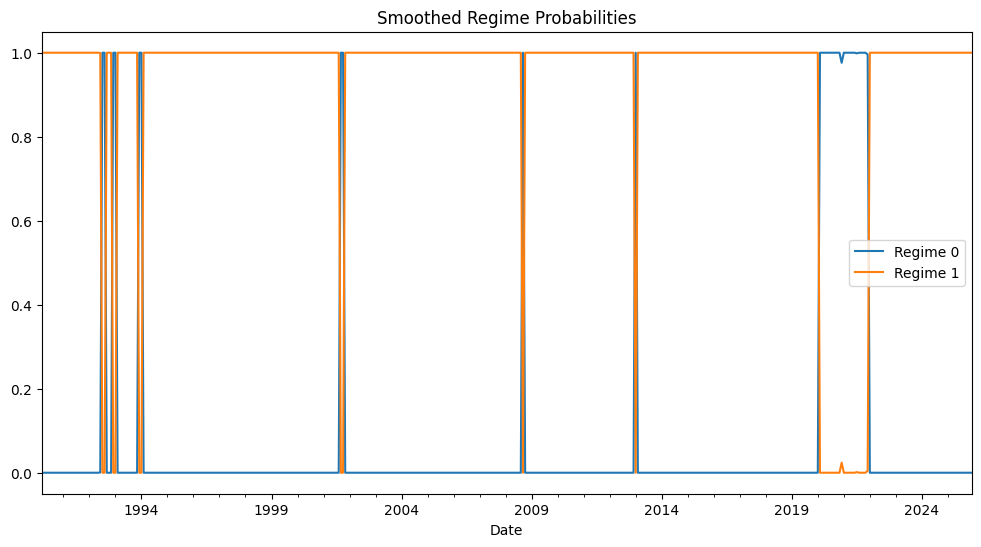

In [8]:
smoothed_probs_df = pd.DataFrame(
    smoothed_probs.T,
    index=dates_train[1:],
    columns=[f"Regime {i}" for i in range(smoothed_probs.shape[0])]
)
smoothed_probs_df.plot(figsize=(12, 6), title="Smoothed Regime Probabilities")
plt.show()

In [9]:
filtered_probs = result.xi_filtered
print("Filtered probs shape:", filtered_probs.shape)
print("Sum to 1:", np.allclose(filtered_probs.sum(axis=0), 1.0))

Filtered probs shape: (2, 430)
Sum to 1: True


In [10]:
states_sequence = result.regime_sequence(use_smoothed=True)
print("State counts:", np.unique(states_sequence, return_counts=True))

State counts: (array([0, 1]), array([ 33, 397]))


### Transition matrix

In [11]:
trans_mat = result.P
pd.DataFrame(
    trans_mat,
    columns=[f"Regime {k}" for k in range(result.K)],
    index=[f"Regime {k}" for k in range(result.K)]
)

,Regime 0,Regime 1
Regime 0,0.786908,0.213092
Regime 1,0.017740,0.982260


In [12]:
print("Average duration in each state (expected number of consecutive months):")
for i, d in enumerate(result.expected_durations):
    print(f"  State {i}: {d:.2f} months")

Average duration in each state (expected number of consecutive months):
  State 0: 4.69 months
  State 1: 56.37 months


## Visualization of results

In [13]:
dates_smooth = dates_train[result.p:]

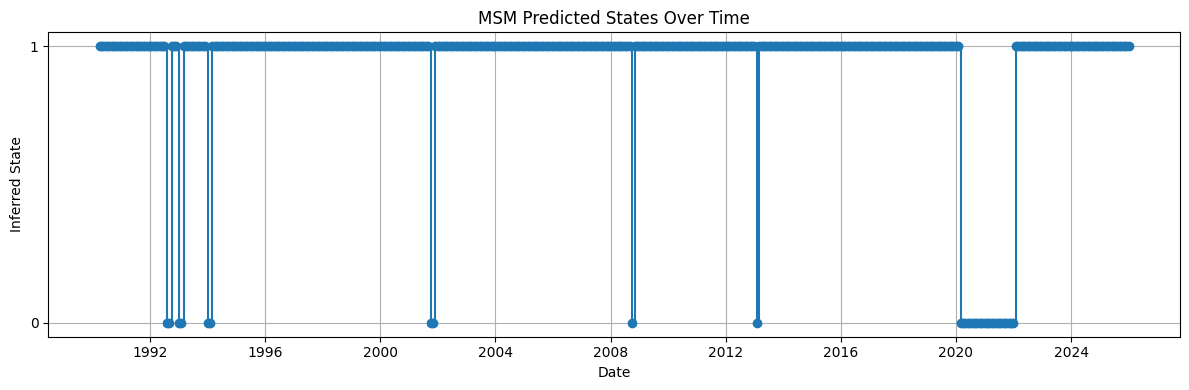

In [14]:
plot_msm_states(dates_smooth, states_sequence, title="MSM Predicted States Over Time")
plt.show()

In [15]:
macro_df_aligned = macro_df.loc[dates_smooth].copy()
macro_df_expanded = macro_df_aligned.copy()
macro_df_expanded["MSM State"] = states_sequence

In [16]:
asset_df = load_asset_data("../data/market_clean.csv")
asset_df.columns = ['Equity', 'Bonds', 'Gold']

asset_df_aligned = asset_df.loc[dates_smooth].copy()
asset_df_expanded = asset_df_aligned.copy()
asset_df_expanded["MSM State"] = macro_df_expanded["MSM State"]

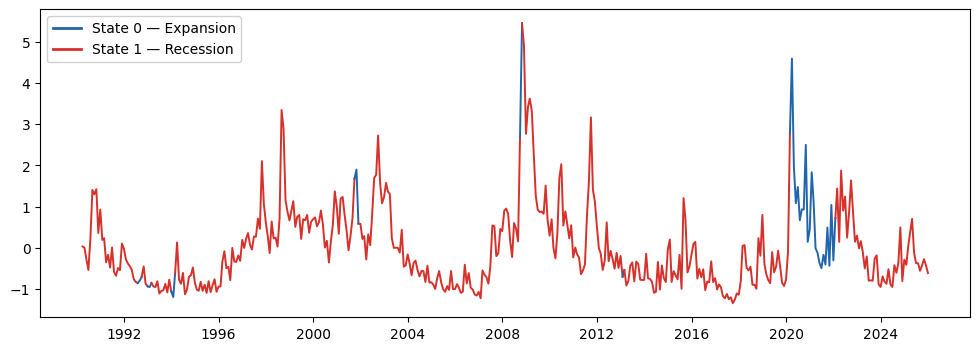

In [17]:
plot_series_colored(macro_df_expanded, series_name='vix', state_col='MSM State')
plt.show()

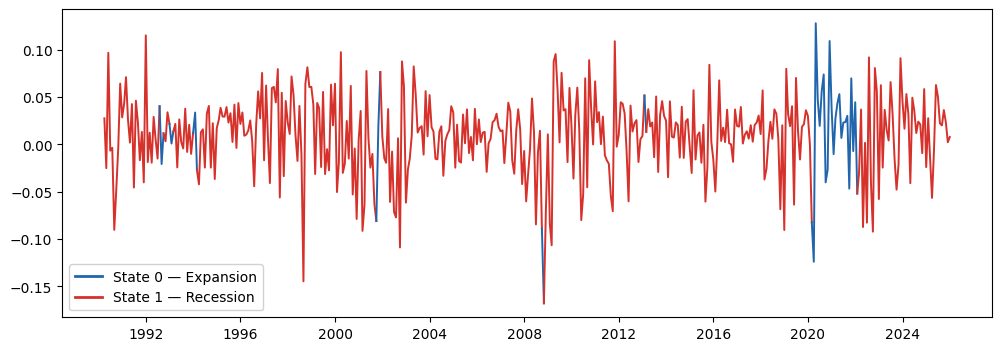

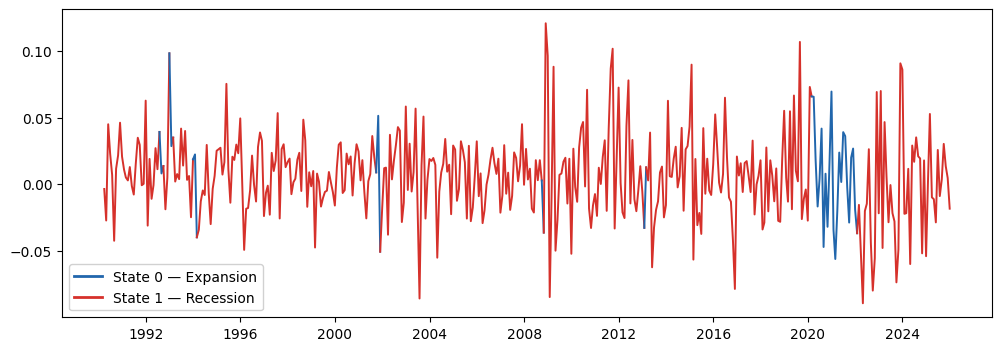

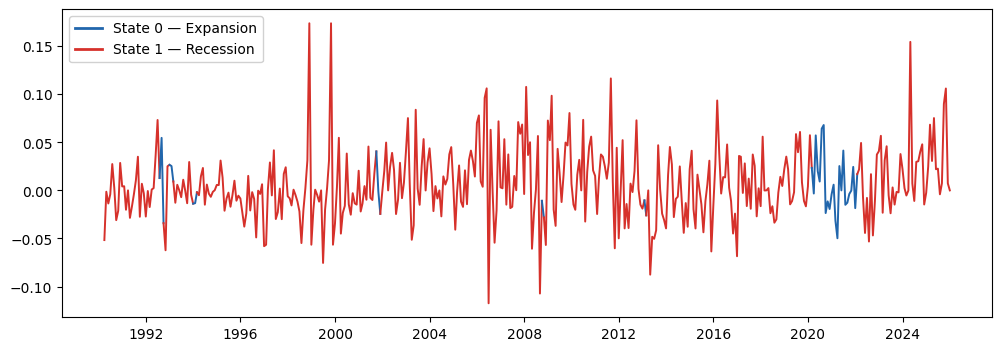

In [18]:
for col in asset_df_aligned.columns:
    plot_series_colored(asset_df_expanded, series_name=col, state_col="MSM State", ax=None)
    plt.show()

## Portfolio optimization

In [19]:
market_train, market_test = train_test_split(asset_df_expanded)
print("Last train date :", market_train.index[-1])
print("First test date :", market_test.index[0])

Last train date : 2018-10-31 00:00:00
First test date : 2018-11-30 00:00:00


In [20]:
moments = estimate_regime_moments(
    market_train,
    asset_cols=market_train.columns[:-1].tolist(),
    state_col="MSM State"
)


── Regime 0  (10 observations) ──
  Mean returns (annualized %):
    Equity      : -1.29%
    Bonds       : +29.43%
    Gold        : +13.22%
  Ledoit-Wolf shrinkage α : 0.9197
  Implied annual volatilities:
    Equity      : 12.59%
    Bonds       : 12.18%
    Gold        : 11.97%

── Regime 1  (334 observations) ──
  Mean returns (annualized %):
    Equity      : +10.86%
    Bonds       : +8.36%
    Gold        : +4.57%
  Ledoit-Wolf shrinkage α : 0.2164
  Implied annual volatilities:
    Equity      : 13.72%
    Bonds       : 10.47%
    Gold        : 12.70%


In [21]:
shrinkage_diagnostics(moments, asset_cols=market_train.columns[:-1].tolist())


── Difference between shrunk and raw covariance ──

Regime 0  (α = 0.9197):
          Equity   Bonds    Gold
  Equity-0.00105-0.00032 0.00035
   Bonds-0.00032 0.00005-0.00017
    Gold 0.00035-0.00017 0.00058

Regime 1  (α = 0.2164):
          Equity   Bonds    Gold
  Equity-0.00009 0.00003 0.00003
   Bonds 0.00003 0.00010-0.00003
    Gold 0.00003-0.00003-0.00002


Regime-Conditional MVO

── min_variance  |  Regime 0 ──
  Expected return (ann.) : +13.93%
  Volatility     (ann.) : 7.09%
  Sharpe ratio          : 1.9661
  Weights:
    Equity      : 0.3177  (31.8%)
    Bonds       : 0.3283  (32.8%)
    Gold        : 0.3540  (35.4%)

── max_sharpe  |  Regime 0 ──
  Expected return (ann.) : +25.30%
  Volatility     (ann.) : 9.55%
  Sharpe ratio          : 2.6493
  Weights:
    Equity      : -0.0363  (-3.6%)
    Bonds       : 0.7125  (71.3%)
    Gold        : 0.3238  (32.4%)

── max_return  |  Regime 0 ──
  Expected return (ann.) : -18.20%
  Volatility     (ann.) : 20.71%
  Sharpe ratio          : -0.8785
  Weights:
    Equity      : 1.5712  (157.1%)
    Bonds       : -0.5315  (-53.1%)
    Gold        : -0.0397  (-4.0%)

── min_variance  |  Regime 1 ──
  Expected return (ann.) : +8.02%
  Volatility     (ann.) : 6.83%
  Sharpe ratio          : 1.1738
  Weights:
    Equity      : 0.2926  (29.3%)
    Bonds       : 0.4242  (42.4%)
    Gold        : 0.2832 

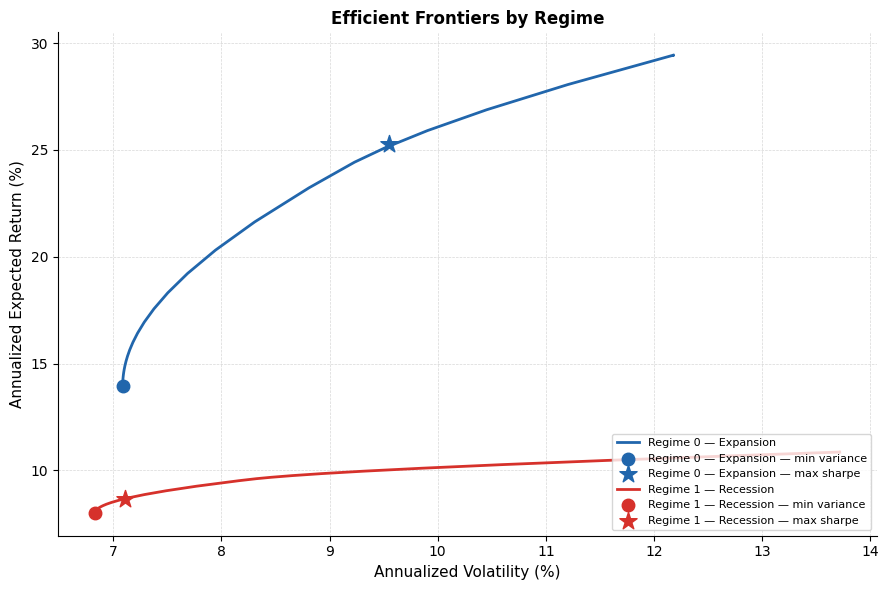

In [22]:
asset_names = market_train.columns[:-1]

print("=" * 55)
print("Regime-Conditional MVO")
print("=" * 55)
results = optimize_regimes(moments, asset_names, rf=0.0, long_only=False)

print("\n" + "=" * 55)
print("Efficient Frontiers")
print("=" * 55)
plot_frontiers(moments, asset_names, results)
plt.show()

### Target weights export

In [23]:
output_path = os.path.join("..", "outputs/tables")
weights_by_regime = {
    k: results[k]['min_variance'].weights
    for k in results
}

states_sequence_series = pd.Series(states_sequence, index=dates_train[1:], name='MSVAR State')
# Switching labels: 0 -> 1, 1 -> 0
states_sequence_series += 1
states_sequence_series[states_sequence_series == 2] = 0

rows = []
for date, regime in states_sequence_series.items():
    w = weights_by_regime[regime]
    rows.append({
        'Date':   date,
        'Regime': regime,
        'Equity': w[0],
        'Bonds':  w[1],
        'Gold':   w[2],
    })

df_target_weights = pd.DataFrame(rows).set_index('Date')
df_target_weights.to_csv(os.path.join(output_path, "msvar_target_weights.csv"))
df_target_weights.head()

,Regime,Equity,Bonds,Gold
Date,,,,
1990-03-31,0,0.317679,0.328343,0.353978
1990-04-30,0,0.317679,0.328343,0.353978
1990-05-31,0,0.317679,0.328343,0.353978
1990-06-30,0,0.317679,0.328343,0.353978
1990-07-31,0,0.317679,0.328343,0.353978


### MVO (Max-Sharpe / Tangency) Portfolio

In [24]:
from src.portfolio import MeanVariancePortfolio

mvo_weights_by_regime = {}
print('MVO (Tangency) Weights:')
print('=' * 55)
for k, m in moments.items():
    mvp = MeanVariancePortfolio(
        mu=m['mu'], Sigma=m['sigma'],
        asset_names=list(asset_names),
        rf=0.0, long_only=True, regime=k,
    )
    res = mvp.tangency()
    mvo_weights_by_regime[k] = res.weights
    print(f'  Regime {k}: Equity={res.weights[0]:.3f}  '
          f'Bonds={res.weights[1]:.3f}  Gold={res.weights[2]:.3f}  '
          f'Sharpe(ann)={res.sharpe * (12**0.5):.3f}')

rows_mvo = []
for date, regime in states_sequence_series.items():
    w = mvo_weights_by_regime[regime]
    rows_mvo.append({'Date': date, 'Regime': regime,
                     'Equity': w[0], 'Bonds': w[1], 'Gold': w[2]})

df_mvo_weights = pd.DataFrame(rows_mvo).set_index('Date')
df_mvo_weights.to_csv(os.path.join(output_path, 'msvar_mvo_target_weights.csv'))
print('\nSaved: msvar_mvo_target_weights.csv')
df_mvo_weights.head()

MVO (Tangency) Weights:
  Regime 0: Equity=0.000  Bonds=0.687  Gold=0.313  Sharpe(ann)=2.646
  Regime 1: Equity=0.374  Bonds=0.463  Gold=0.163  Sharpe(ann)=1.221

Saved: msvar_mvo_target_weights.csv


,Regime,Equity,Bonds,Gold
Date,,,,
1990-03-31,0,2.329108e-09,0.686784,0.313216
1990-04-30,0,2.329108e-09,0.686784,0.313216
1990-05-31,0,2.329108e-09,0.686784,0.313216
1990-06-30,0,2.329108e-09,0.686784,0.313216
1990-07-31,0,2.329108e-09,0.686784,0.313216


In [25]:
from src.backtest import backtest_with_transaction_costs
from src.data_loader import load_asset_data
from src.constants import ASSET_COLS

asset_returns_full = load_asset_data('../data/market_clean.csv')[ASSET_COLS].sort_index()

mvo_test_weights = df_mvo_weights.rename(columns={
    'Equity': 'index_fund', 'Bonds': 'treasury_fund', 'Gold': 'gold_fund'
})

SIGNAL_START_MSVAR = pd.Timestamp('2018-11-30')
mvo_test_weights = mvo_test_weights.loc[mvo_test_weights.index >= SIGNAL_START_MSVAR].copy()

result_mvo = backtest_with_transaction_costs(
    target_weights=mvo_test_weights,
    asset_returns=asset_returns_full,
    transaction_cost_bps=10,
    apply_signal_lag=True,
    include_initial_trade_cost=False,
)

first_date = result_mvo.index[0]
result_mvo.loc[first_date, 'trade_notional']         = 0.0
result_mvo.loc[first_date, 'one_way_turnover']       = 0.0
result_mvo.loc[first_date, 'transaction_cost']       = 0.0
result_mvo.loc[first_date, 'net_return_after_costs'] = result_mvo.loc[first_date, 'gross_return']

result_mvo.to_csv(os.path.join(output_path, 'msvar_mvo_monthly_returns_with_costs.csv'))
print(f'Test period: {result_mvo.index.min().date()} to {result_mvo.index.max().date()}')

net_ret = result_mvo['net_return_after_costs']
geo_mean = (1 + net_ret).prod() ** (12 / len(net_ret)) - 1
vol = net_ret.std() * np.sqrt(12)
sharpe = (geo_mean - 0.02664) / vol
print(f'\nMSVAR-MVO (net of costs):')
print(f'  Ann. return (geo): {geo_mean*100:.2f}%')
print(f'  Ann. volatility  : {vol*100:.2f}%')
print(f'  Sharpe ratio     : {sharpe:.3f}')

Test period: 2018-12-31 to 2025-12-31

MSVAR-MVO (net of costs):
  Ann. return (geo): 8.92%
  Ann. volatility  : 11.44%
  Sharpe ratio     : 0.547


## Regime-Shaded Indicator Plots: VIX, FEDFUNDS, and UNRATE

Line color reflects model-classified state; NBER recession bands provide an independent reference.
Note: recession_state=0 for MSVAR (label 0 = contraction).

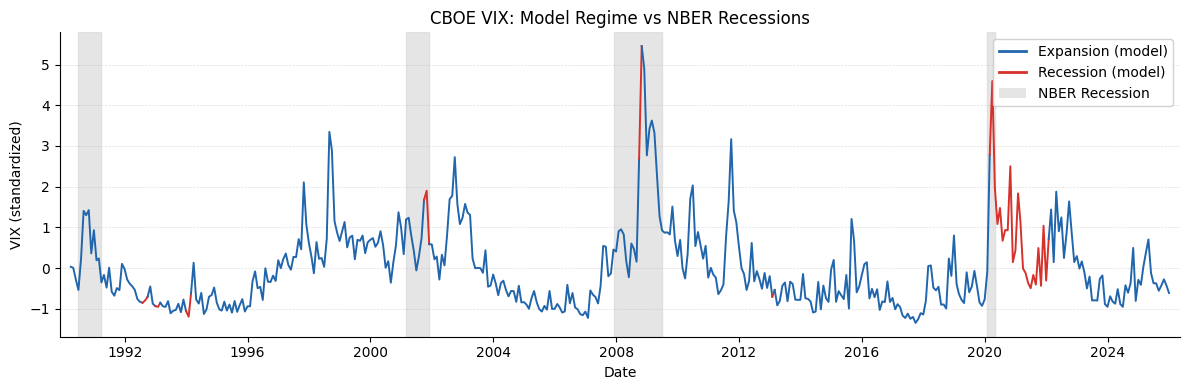

In [26]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_regime_nber(
    macro_df_expanded, series_name='vix', state_col='MSM State',
    recession_state=0,
    title='CBOE VIX: Model Regime vs NBER Recessions',
    ylabel='VIX (standardized)', ax=ax
)
plt.tight_layout()
plt.show()

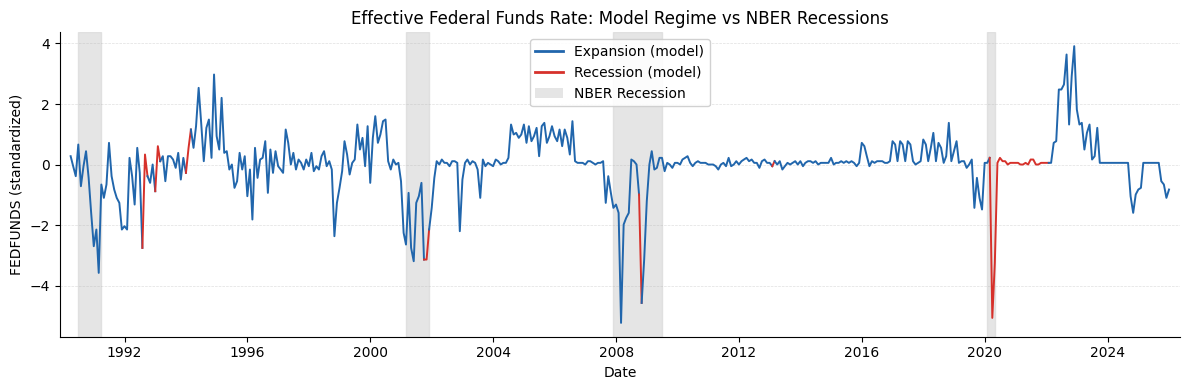

In [27]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_regime_nber(
    macro_df_expanded, series_name='fed_funds_rate', state_col='MSM State',
    recession_state=0,
    title='Effective Federal Funds Rate: Model Regime vs NBER Recessions',
    ylabel='FEDFUNDS (standardized)', ax=ax
)
plt.tight_layout()
plt.show()

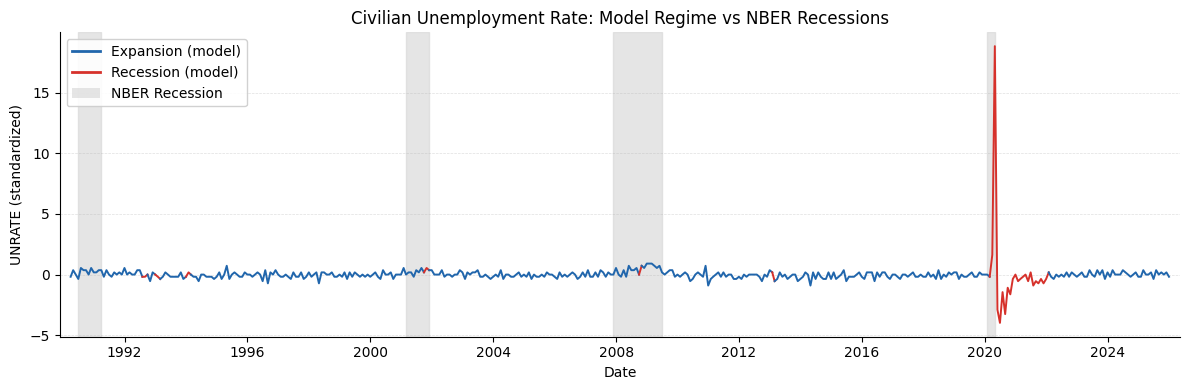

In [28]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_regime_nber(
    macro_df_expanded, series_name='unemployment_rate', state_col='MSM State',
    recession_state=0,
    title='Civilian Unemployment Rate: Model Regime vs NBER Recessions',
    ylabel='UNRATE (standardized)', ax=ax
)
plt.tight_layout()
plt.show()

## Robustness Check: K = 3 Regimes

AIC and BIC are used for model selection (LR test is non-standard under H0: K=2).

In [29]:
result_k3 = em_fit(
    data=X_train,
    K=3,
    p=1,
    n_restarts=3,
    max_iter=200,
    tol=1e-5,
    random_state=42,
    verbose=True
)


--- Restart 1/3 ---
  iter    0 | log-lik = -4180.424797 | Δ = inf
  iter   10 | log-lik = -3344.265248 | Δ = 1.26e+00
  iter   20 | log-lik = -3322.306955 | Δ = 1.48e+00
  iter   30 | log-lik = -3314.797636 | Δ = 2.53e-04
  Converged at iteration 36.

--- Restart 2/3 ---
  iter    0 | log-lik = -4278.942989 | Δ = inf
  iter   10 | log-lik = -3371.846969 | Δ = 3.97e+00
  iter   20 | log-lik = -3359.878753 | Δ = 9.39e-03
  Converged at iteration 29.

--- Restart 3/3 ---
  iter    0 | log-lik = -4290.797361 | Δ = inf
  iter   10 | log-lik = -2863.027043 | Δ = 1.27e+01
  iter   20 | log-lik = -2820.186329 | Δ = 1.74e+00
  iter   30 | log-lik = -2818.593564 | Δ = 4.05e-03
  iter   40 | log-lik = -2818.583804 | Δ = 1.25e-04
  Converged at iteration 47.


In [30]:
T = X_train.shape[0]
ll_k2 = result.log_likelihood
n_params_k2 = result.n_params
ll_k3 = result_k3.log_likelihood
n_params_k3 = result_k3.n_params

lr_stat = 2 * (ll_k3 - ll_k2)
delta_df = n_params_k3 - n_params_k2

summary_k3 = pd.DataFrame({
    'K': [2, 3],
    'Log-Likelihood': [ll_k2, ll_k3],
    'N Parameters':   [n_params_k2, n_params_k3],
    'AIC': [-2*ll_k2 + 2*n_params_k2, -2*ll_k3 + 2*n_params_k3],
    'BIC': [-2*ll_k2 + n_params_k2*np.log(T), -2*ll_k3 + n_params_k3*np.log(T)],
})
print(f'LR statistic (K=2 vs K=3): {lr_stat:.2f}  (delta_df = {delta_df})')
summary_k3

LR statistic (K=2 vs K=3): 1638.68  (delta_df = 277)


,K,Log-Likelihood,N Parameters,AIC,BIC
0,2,-3637.925198,548,8371.850395,10600.077628
1,3,-2818.583539,825,7287.167078,10641.706252


In [31]:
states_k3 = result_k3.regime_sequence(use_smoothed=True)
print('K=3 state counts:', dict(zip(*np.unique(states_k3, return_counts=True))))

key_vars = ['vix', 'credit_spread', 'unemployment_rate',
            'industrial_production', 'fed_funds_rate']
key_idx  = [list(macro_df.columns).index(v) for v in key_vars]

means_k3 = pd.DataFrame(
    {f'State {k}': result_k3.B_list[k][:, 0][key_idx] for k in range(3)},
    index=key_vars
)
means_k3

K=3 state counts: {np.int64(0): np.int64(55), np.int64(1): np.int64(351), np.int64(2): np.int64(24)}


,State 0,State 1,State 2
vix,0.011738,-0.009124,0.152393
credit_spread,-0.067091,0.002831,0.101312
unemployment_rate,0.023210,-0.023831,-0.070225
industrial_production,-0.231255,0.078654,0.125183
fed_funds_rate,0.026654,-0.008789,-0.279225


In [32]:
summary_k3.to_csv(os.path.join(output_path, 'msvar_k3_model_selection.csv'), index=False)
means_k3.to_csv(os.path.join(output_path, 'msvar_k3_regime_means.csv'))
print('Saved K=3 MSVAR results.')

Saved K=3 MSVAR results.
